In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:\ML_Mily\Obesity_Prediction\ObesityDataSet.csv')

In [3]:
df.head

<bound method NDFrame.head of       Gender        Age    Height      Weight family_history_with_overweight  \
0     Female  21.000000  1.620000   64.000000                            yes   
1     Female  21.000000  1.520000   56.000000                            yes   
2       Male  23.000000  1.800000   77.000000                            yes   
3       Male  27.000000  1.800000   87.000000                             no   
4       Male  22.000000  1.780000   89.800000                             no   
...      ...        ...       ...         ...                            ...   
2106  Female  20.976842  1.710730  131.408528                            yes   
2107  Female  21.982942  1.748584  133.742943                            yes   
2108  Female  22.524036  1.752206  133.689352                            yes   
2109  Female  24.361936  1.739450  133.346641                            yes   
2110  Female  23.664709  1.738836  133.472641                            yes   

     FAVC

In [4]:
# Feature Engineering
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['Weight_Height_Interaction'] = df['Weight'] * df['Height']
df['Age_Binned'] = pd.qcut(df['Age'], q=4, labels=['Young', 'Middle', 'Older', 'Senior'])
df['BMI_Binned'] = pd.qcut(df['BMI'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [5]:
# Feature engineered columns
print(df.head())
print(df.iloc[0])


   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  ...  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no  ...   no  0.0  1.0          no   
1  3.0  Sometimes   yes  ...  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no  ...   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no  ...   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no  ...   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad        BMI  \
0  Public_Transportation        Normal_Weight  24.386526   
1  Public_Transportation        Normal_Weight  24.238227   
2 

In [6]:
# Check for null values and duplicates
print("Null Values:")
print(df.isnull().sum())
print("Duplicate Rows Before Removal:", df[df.duplicated()].shape[0])
df.drop_duplicates(inplace=True)
print("Duplicate Rows After Removal:", df[df.duplicated()].shape[0])

Null Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
BMI                               0
Weight_Height_Interaction         0
Age_Binned                        0
BMI_Binned                        0
dtype: int64
Duplicate Rows Before Removal: 24
Duplicate Rows After Removal: 0


In [7]:
# Define features and target
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']
print("Target:", y)

Target: 0             Normal_Weight
1             Normal_Weight
2             Normal_Weight
3        Overweight_Level_I
4       Overweight_Level_II
               ...         
2106       Obesity_Type_III
2107       Obesity_Type_III
2108       Obesity_Type_III
2109       Obesity_Type_III
2110       Obesity_Type_III
Name: NObeyesdad, Length: 2087, dtype: object


In [8]:
# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'Age_Binned', 'BMI_Binned'],
      dtype='object')
Numerical Columns: Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI',
       'Weight_Height_Interaction'],
      dtype='object')


In [10]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False))
        ]), categorical_cols)
    ])

In [11]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# Create pipeline with preprocessing, SMOTE, and undersampling
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42))
])

In [13]:
# Apply preprocessing and balancing
X_train, y_train = pipeline.named_steps['smote'].fit_resample(
    pipeline.named_steps['preprocessor'].fit_transform(X_train), y_train)
X_test = pipeline.named_steps['preprocessor'].transform(X_test)

In [14]:
# Feature selection with RFE
rf_for_rfe = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf_for_rfe, n_features_to_select=20)
X_train = rfe.fit_transform(X_train, y_train)
X_test = rfe.transform(X_test)

In [15]:
# Define models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

## Hyperparameter tuning ##

In [16]:
# RandomForest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_rf.fit(X_train, y_train)
best_rf = random_rf.best_estimator_
print(f"Best RandomForest Parameters: {random_rf.best_params_}")

Best RandomForest Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [17]:
# XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.9, 1.0]
}
random_xgb = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), param_grid_xgb, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_xgb.fit(X_train, y_train)
best_xgb = random_xgb.best_estimator_
print(f"Best XGBoost Parameters: {random_xgb.best_params_}")

Best XGBoost Parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3}


In [18]:
# Update models with tuned versions
models['RandomForest'] = best_rf
models['XGBoost'] = best_xgb

In [19]:
# Import StackingClassifier
from sklearn.ensemble import StackingClassifier

In [20]:
# Stacking ensemble
estimators = [
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('cat', CatBoostClassifier(random_state=42, verbose=0))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(max_iter=1000), cv=5)
models['Stacking'] = stacking_model

In [21]:
# Voting ensemble
voting_model = VotingClassifier(estimators=estimators, voting='soft')
models['Voting'] = voting_model

In [22]:
# Function to plot learning curves
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
    plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid()
    plt.show()

In [23]:
# Train the models
for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model {model_name} trained successfully.")


Model RandomForest trained successfully.
Model GradientBoosting trained successfully.
Model SVM trained successfully.
Model KNN trained successfully.
Model XGBoost trained successfully.
Model CatBoost trained successfully.
Model Stacking trained successfully.
Model Voting trained successfully.


In [24]:
# Evaluate the models in detail
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Model {model_name} Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print("\n")

Model RandomForest Evaluation Metrics:
Accuracy: 0.981
Precision: 0.982
Recall: 0.981
F1 Score: 0.981


Model GradientBoosting Evaluation Metrics:
Accuracy: 0.976
Precision: 0.977
Recall: 0.976
F1 Score: 0.976


Model SVM Evaluation Metrics:
Accuracy: 0.950
Precision: 0.952
Recall: 0.950
F1 Score: 0.949


Model KNN Evaluation Metrics:
Accuracy: 0.933
Precision: 0.932
Recall: 0.933
F1 Score: 0.932


Model XGBoost Evaluation Metrics:
Accuracy: 0.983
Precision: 0.983
Recall: 0.983
F1 Score: 0.983


Model CatBoost Evaluation Metrics:
Accuracy: 0.981
Precision: 0.982
Recall: 0.981
F1 Score: 0.981


Model Stacking Evaluation Metrics:
Accuracy: 0.983
Precision: 0.984
Recall: 0.983
F1 Score: 0.983


Model Voting Evaluation Metrics:
Accuracy: 0.983
Precision: 0.984
Recall: 0.983
F1 Score: 0.983




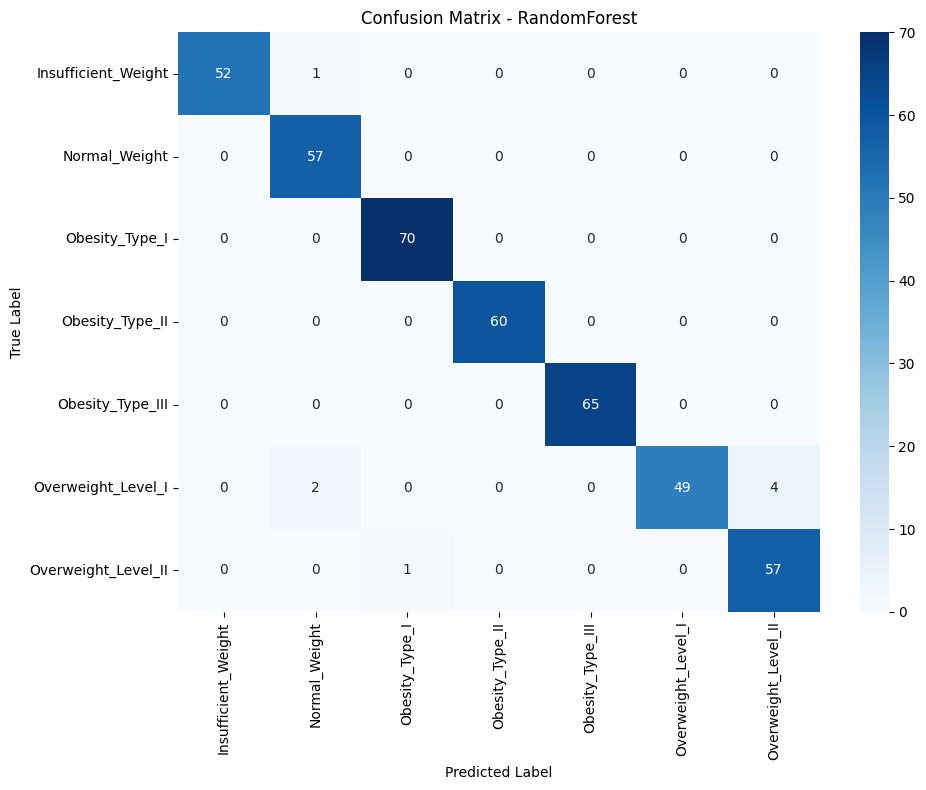


Classification Report for RandomForest:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.95      1.00      0.97        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      0.89      0.94        55
Overweight_Level_II       0.93      0.98      0.96        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


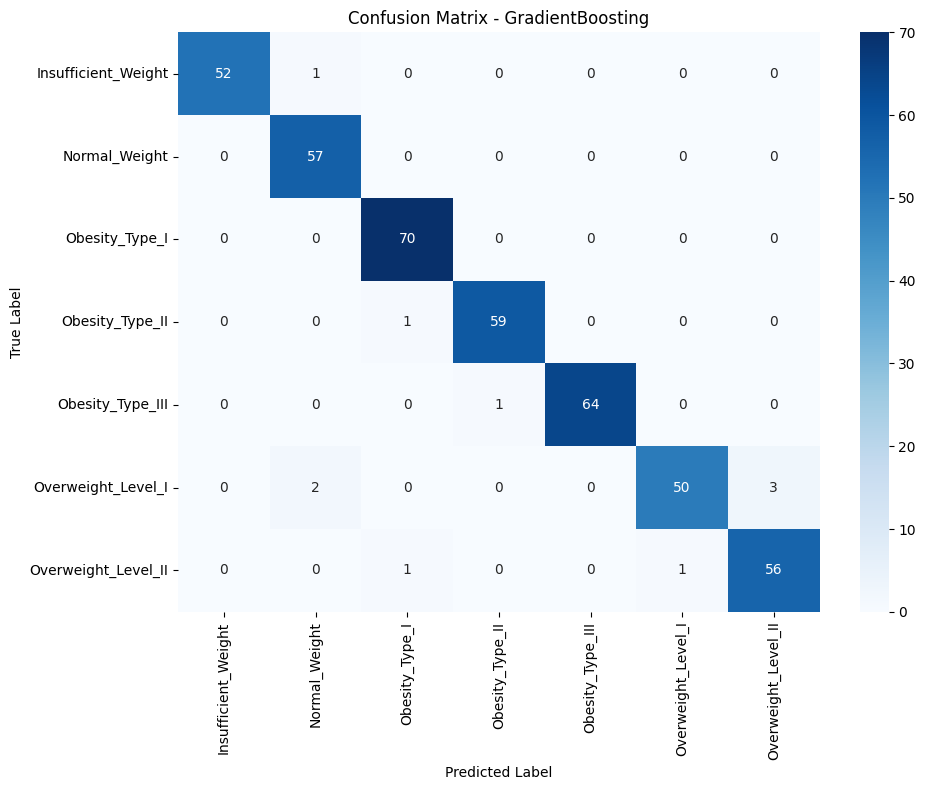


Classification Report for GradientBoosting:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.95      1.00      0.97        57
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.91      0.94        55
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.98       418
          macro avg       0.98      0.97      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


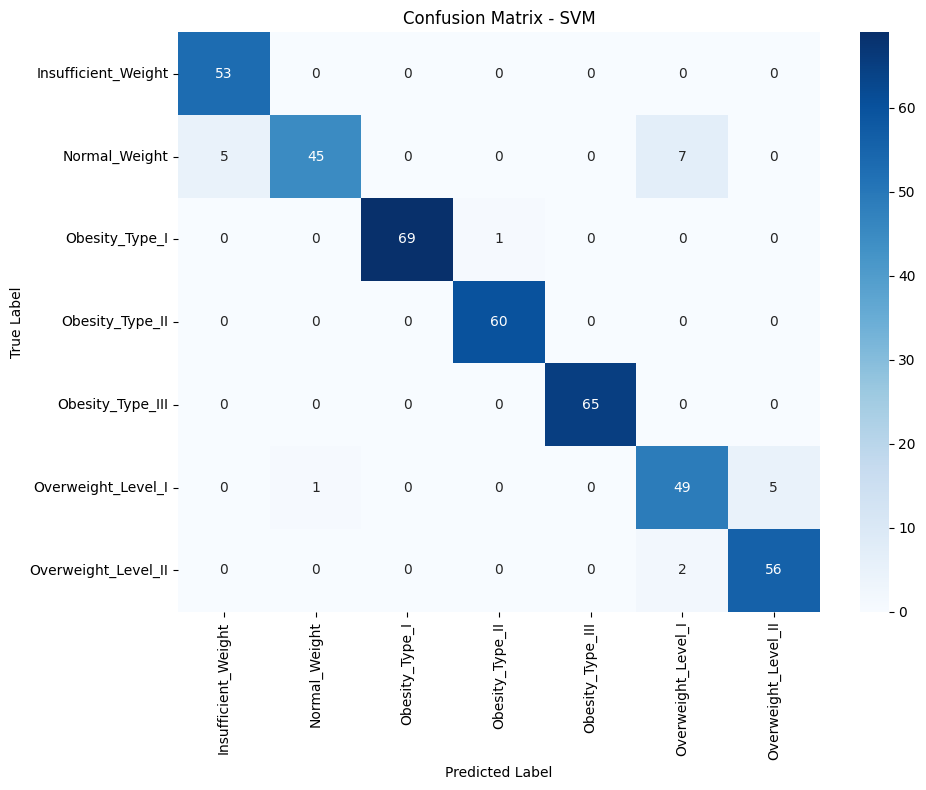


Classification Report for SVM:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      1.00      0.95        53
      Normal_Weight       0.98      0.79      0.87        57
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.84      0.89      0.87        55
Overweight_Level_II       0.92      0.97      0.94        58

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418

--------------------------------------------------------------------------------


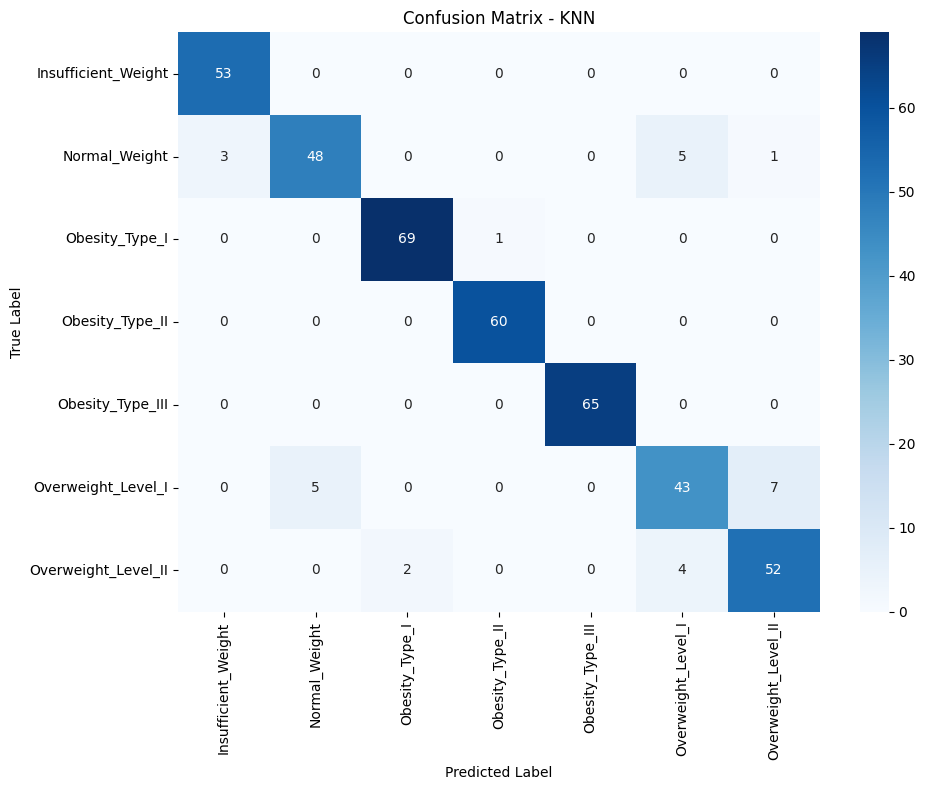


Classification Report for KNN:
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.91      0.84      0.87        57
     Obesity_Type_I       0.97      0.99      0.98        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.83      0.78      0.80        55
Overweight_Level_II       0.87      0.90      0.88        58

           accuracy                           0.93       418
          macro avg       0.93      0.93      0.93       418
       weighted avg       0.93      0.93      0.93       418

--------------------------------------------------------------------------------


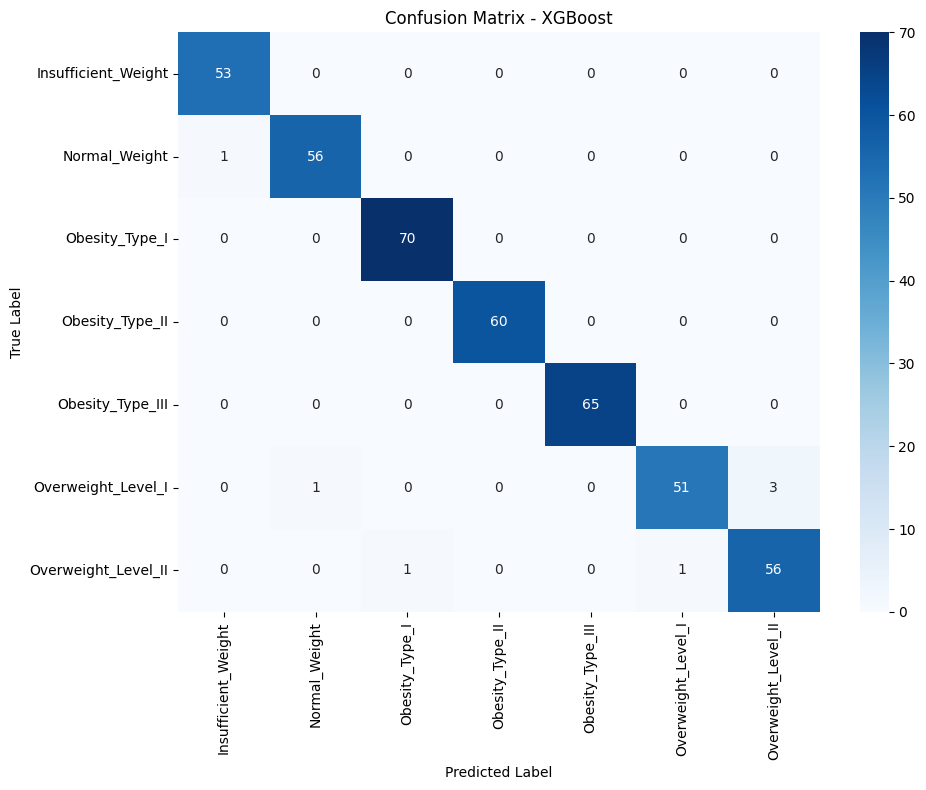


Classification Report for XGBoost:
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.98      0.98      0.98        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.98      0.93      0.95        55
Overweight_Level_II       0.95      0.97      0.96        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


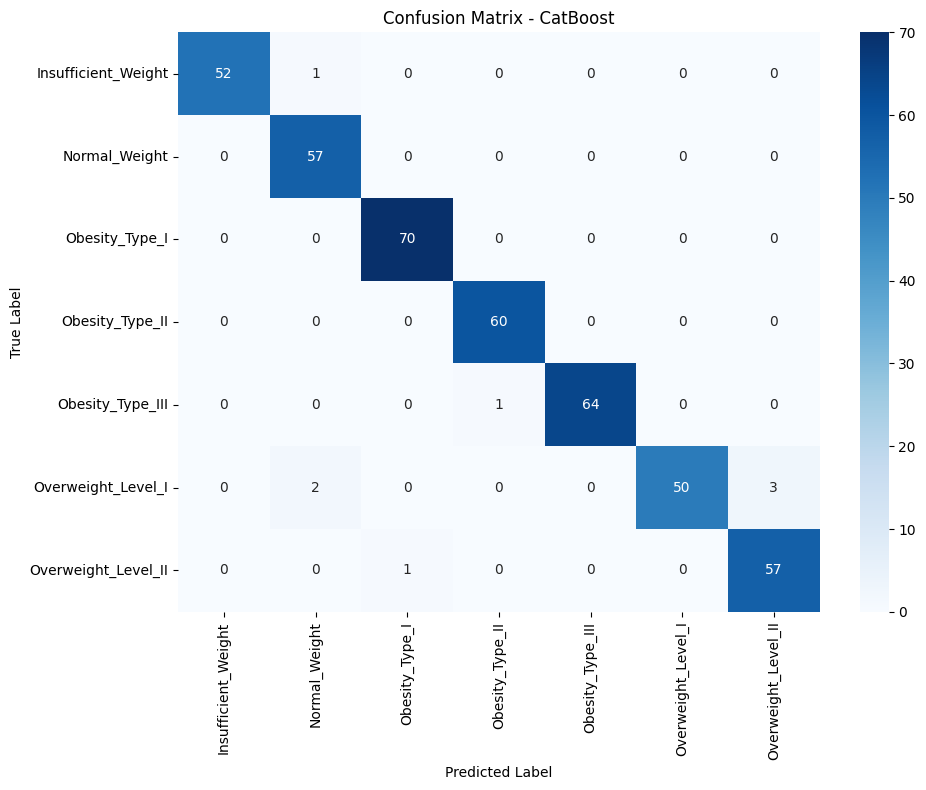


Classification Report for CatBoost:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.95      1.00      0.97        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.91      0.95        55
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


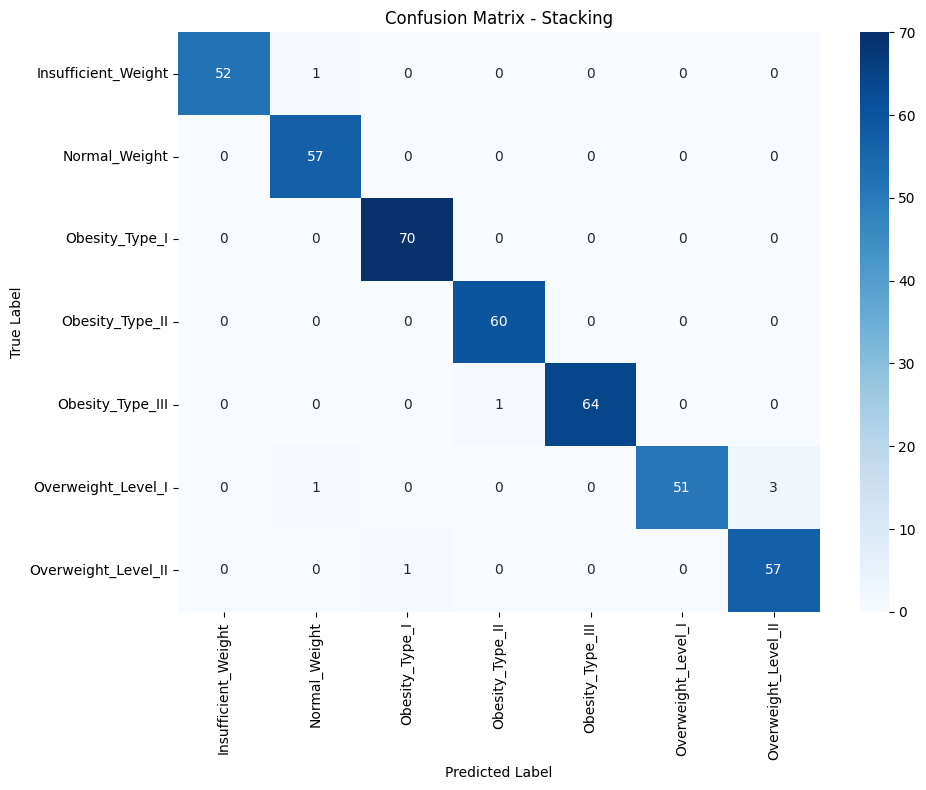


Classification Report for Stacking:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.97      1.00      0.98        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.93      0.96        55
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


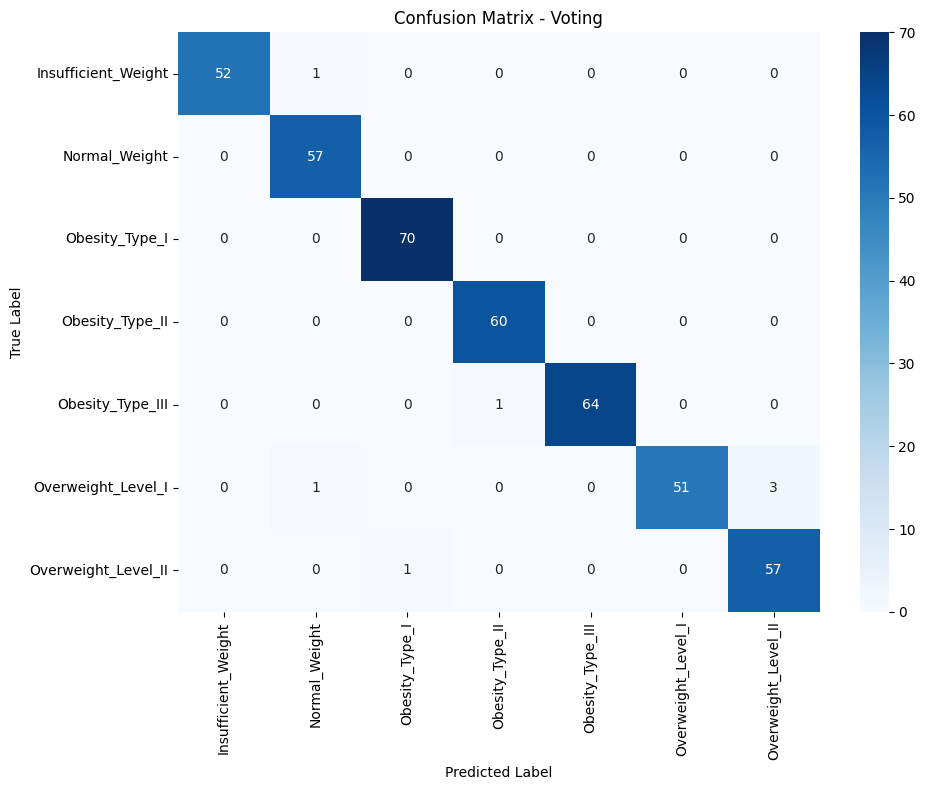


Classification Report for Voting:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.97      1.00      0.98        57
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.93      0.96        55
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418

--------------------------------------------------------------------------------


In [25]:
# First, recreate the LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['NObeyesdad'])

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, 
                yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for all models
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, model_name)
    
    # Print classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("-" * 80)

<Figure size 1200x800 with 0 Axes>

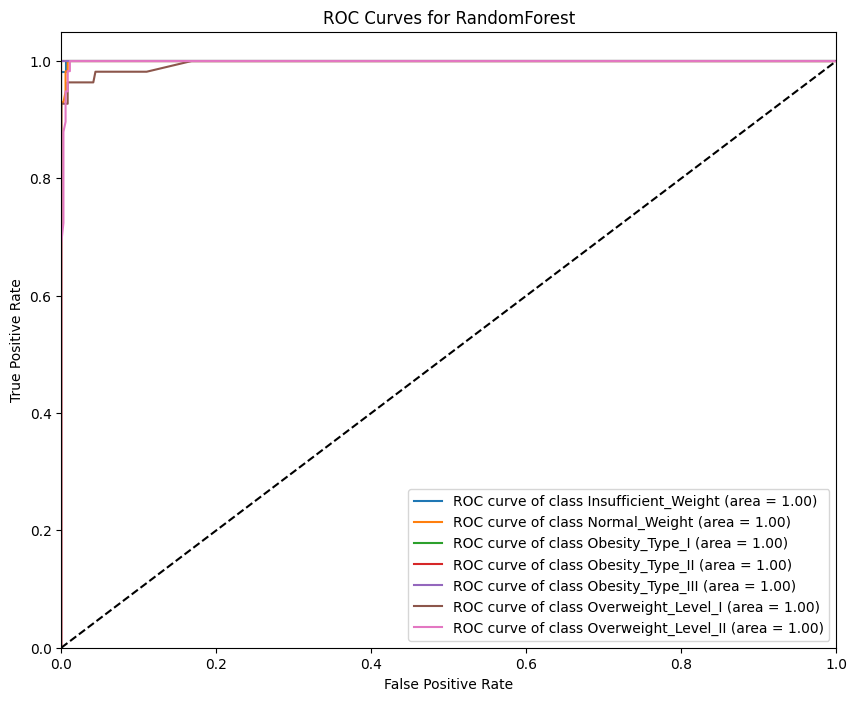


AUC Scores for RandomForest:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 1.000
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.996
Class Overweight_Level_II: 0.999
Micro-average AUC: 0.999
--------------------------------------------------------------------------------


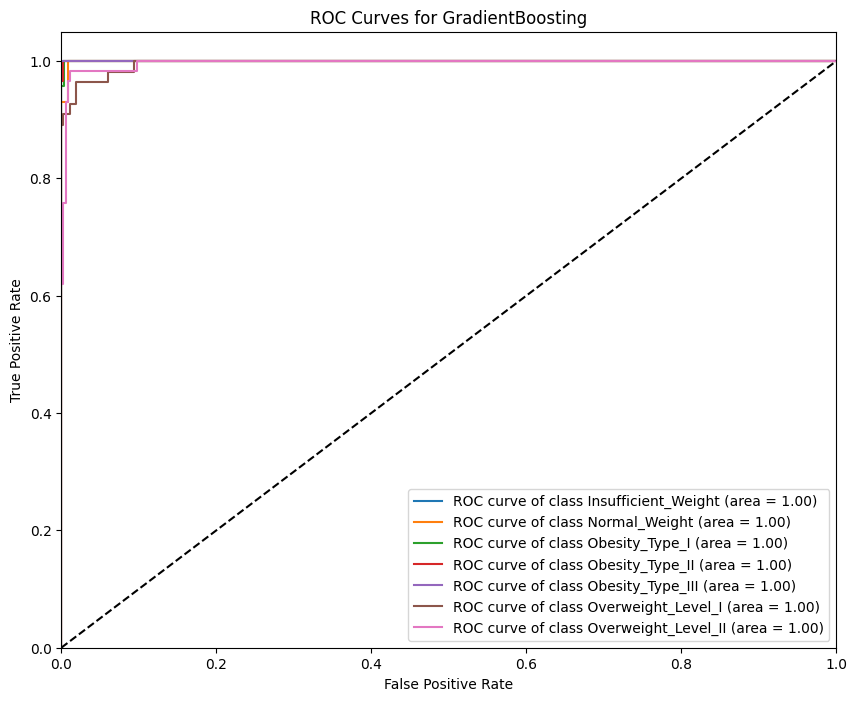


AUC Scores for GradientBoosting:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 0.999
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.996
Class Overweight_Level_II: 0.997
Micro-average AUC: 0.999
--------------------------------------------------------------------------------


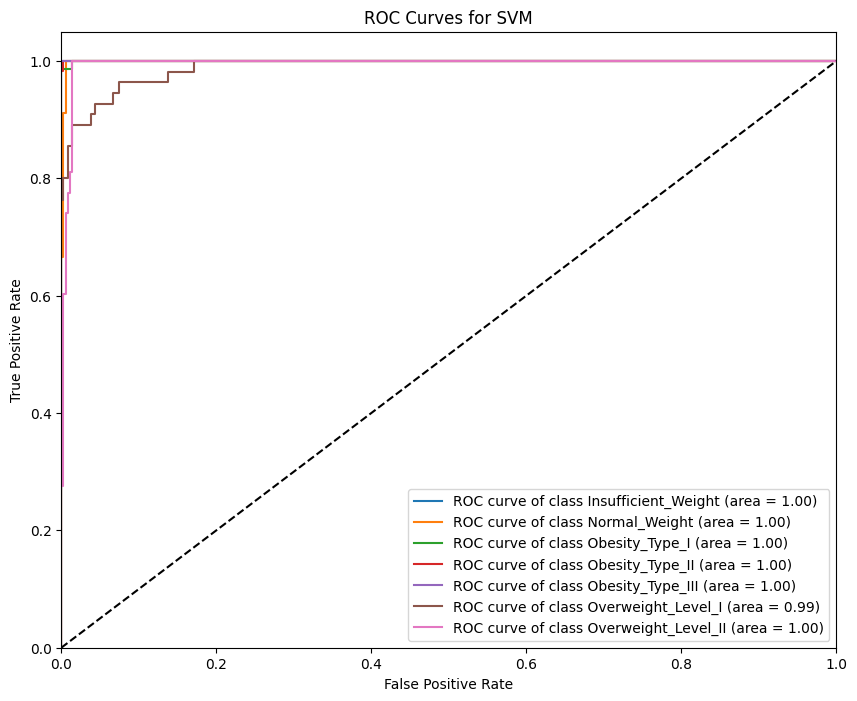


AUC Scores for SVM:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 0.999
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.989
Class Overweight_Level_II: 0.995
Micro-average AUC: 0.998
--------------------------------------------------------------------------------


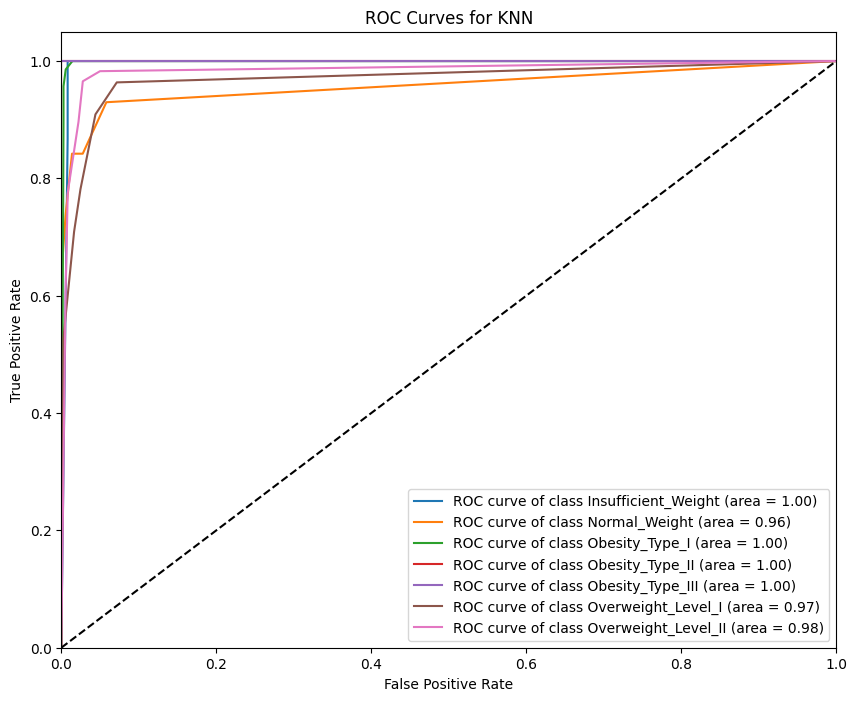


AUC Scores for KNN:
Class Insufficient_Weight: 0.995
Class Normal_Weight: 0.958
Class Obesity_Type_I: 0.998
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.969
Class Overweight_Level_II: 0.984
Micro-average AUC: 0.988
--------------------------------------------------------------------------------


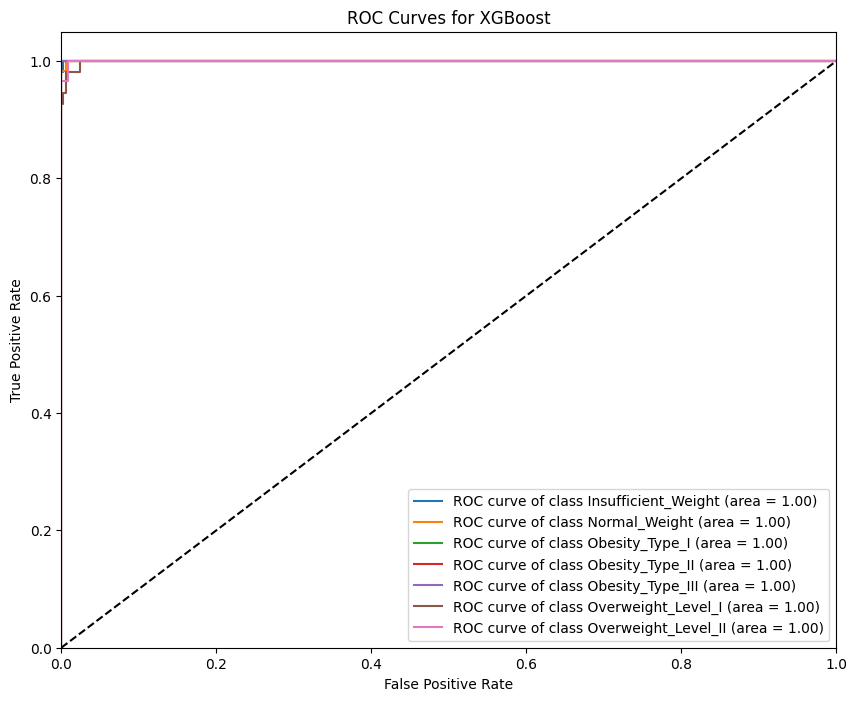


AUC Scores for XGBoost:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 1.000
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.999
Class Overweight_Level_II: 1.000
Micro-average AUC: 1.000
--------------------------------------------------------------------------------


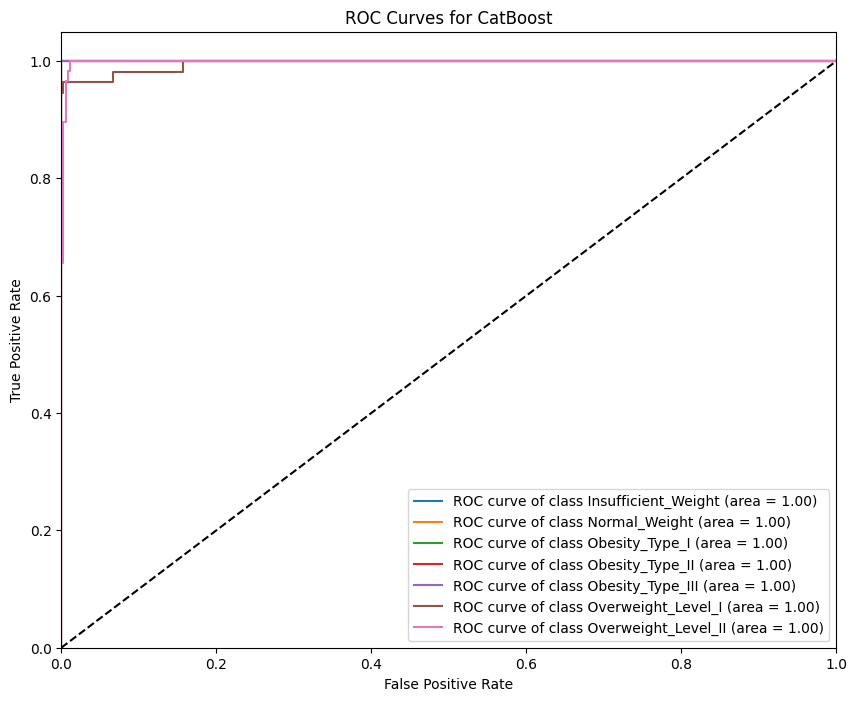


AUC Scores for CatBoost:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 1.000
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.996
Class Overweight_Level_II: 0.999
Micro-average AUC: 0.999
--------------------------------------------------------------------------------


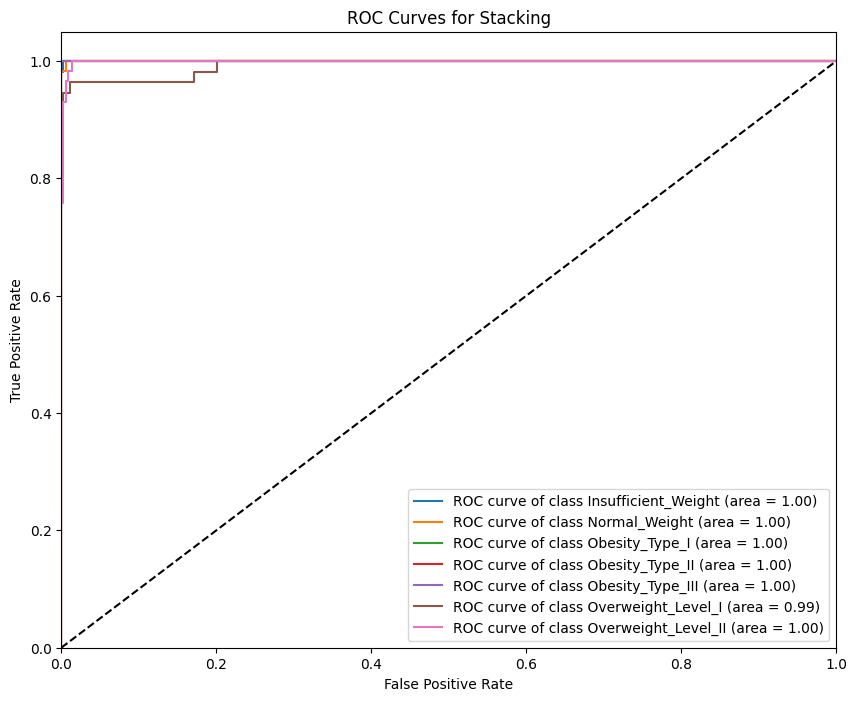


AUC Scores for Stacking:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 1.000
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.993
Class Overweight_Level_II: 0.999
Micro-average AUC: 1.000
--------------------------------------------------------------------------------


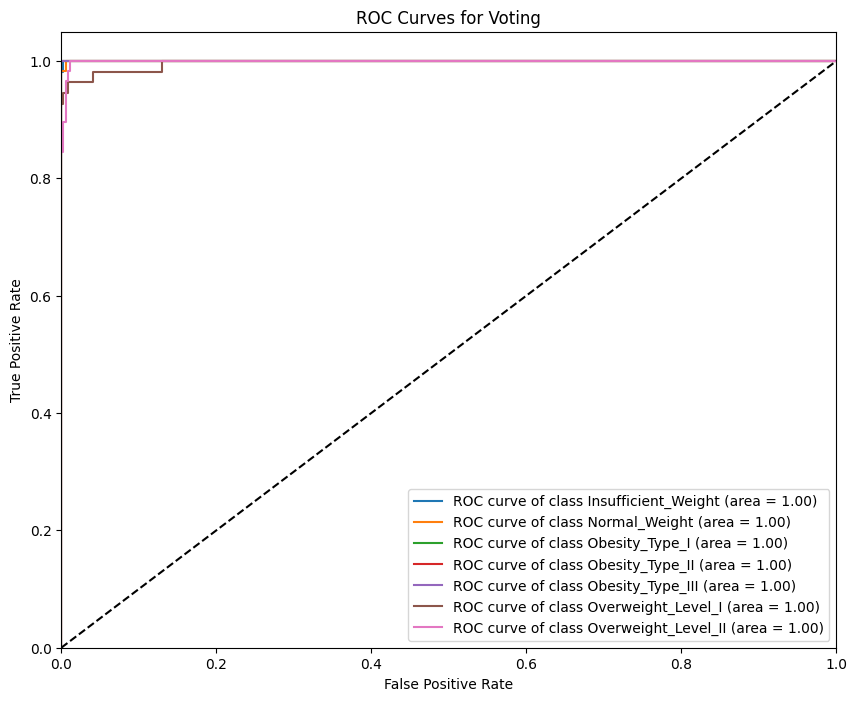


AUC Scores for Voting:
Class Insufficient_Weight: 1.000
Class Normal_Weight: 1.000
Class Obesity_Type_I: 1.000
Class Obesity_Type_II: 1.000
Class Obesity_Type_III: 1.000
Class Overweight_Level_I: 0.997
Class Overweight_Level_II: 0.999
Micro-average AUC: 1.000
--------------------------------------------------------------------------------


In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the output
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))

# Plot ROC curves for each model
plt.figure(figsize=(12, 8))
for model_name, model in models.items():
    # Get probability predictions
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    else:
        # For models that don't have predict_proba, use decision_function
        y_score = model.decision_function(X_test)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(le.classes_)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot ROC curve for each class
    plt.figure(figsize=(10, 8))
    for i in range(len(le.classes_)):
        plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {le.classes_[i]} (area = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for {model_name}')
    plt.legend(loc="lower right")
    plt.show()
    
    # Print AUC scores
    print(f"\nAUC Scores for {model_name}:")
    for i in range(len(le.classes_)):
        print(f"Class {le.classes_[i]}: {roc_auc[i]:.3f}")
    print(f"Micro-average AUC: {roc_auc['micro']:.3f}")
    print("-" * 80)

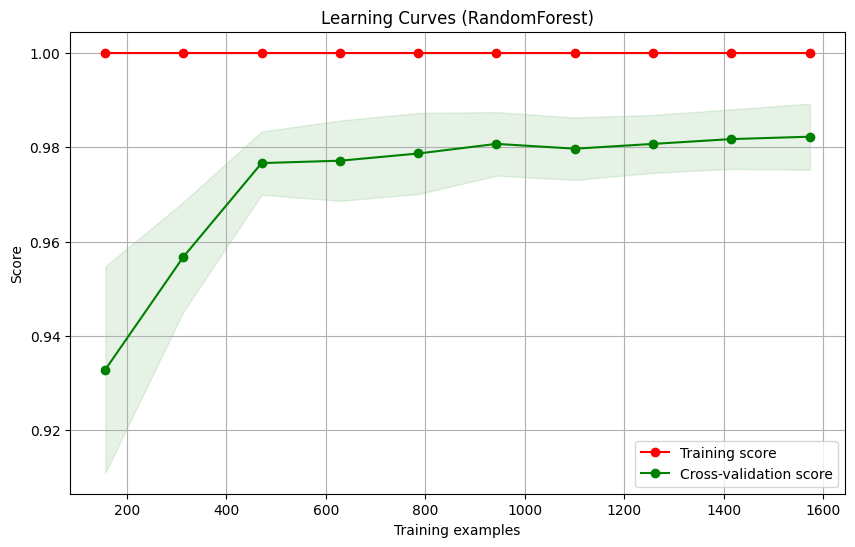


Final Scores for RandomForest:
Training Score: 1.000
Validation Score: 0.982
Gap: 0.018
--------------------------------------------------------------------------------


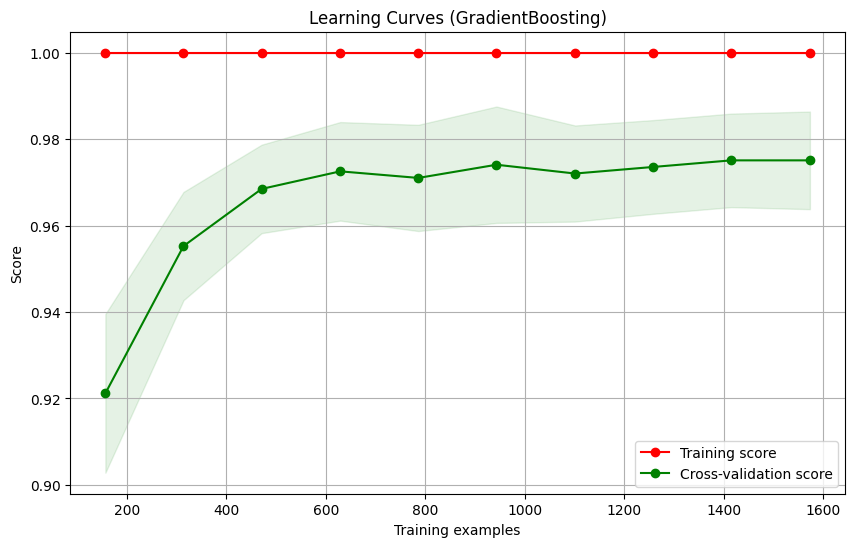


Final Scores for GradientBoosting:
Training Score: 1.000
Validation Score: 0.975
Gap: 0.025
--------------------------------------------------------------------------------


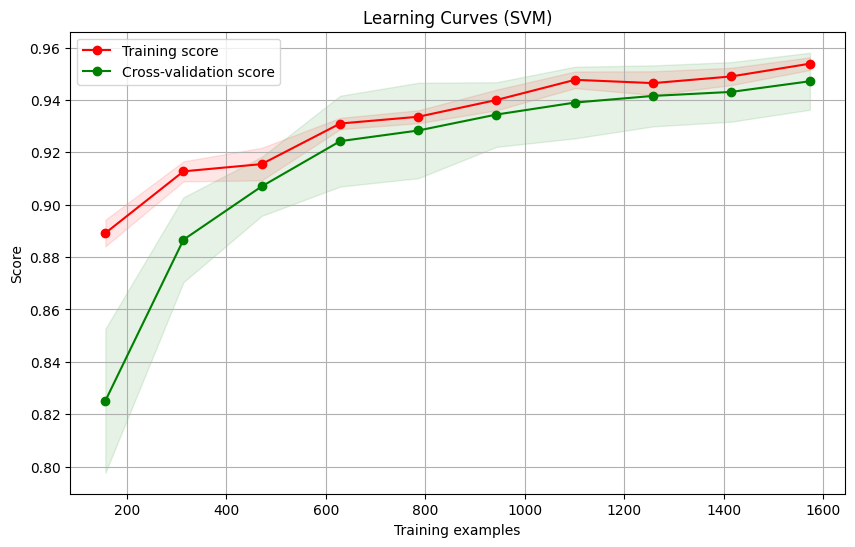


Final Scores for SVM:
Training Score: 0.954
Validation Score: 0.947
Gap: 0.007
--------------------------------------------------------------------------------


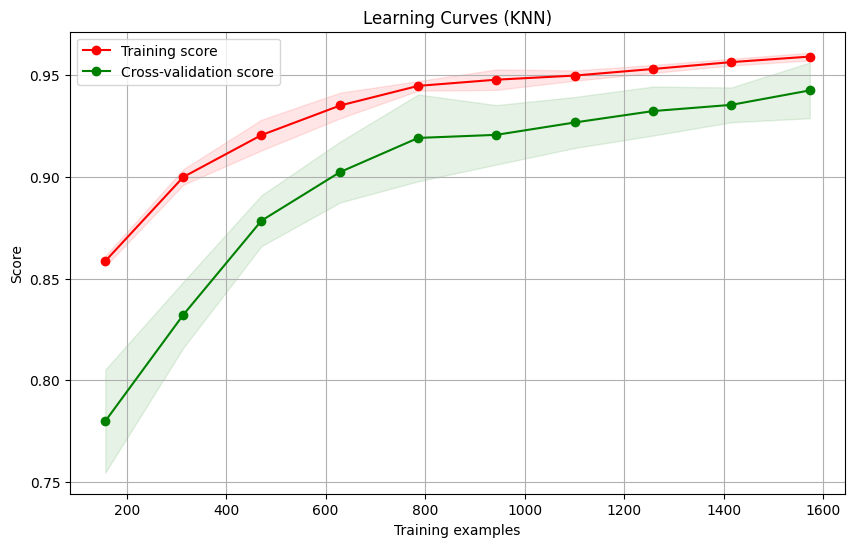


Final Scores for KNN:
Training Score: 0.959
Validation Score: 0.943
Gap: 0.017
--------------------------------------------------------------------------------


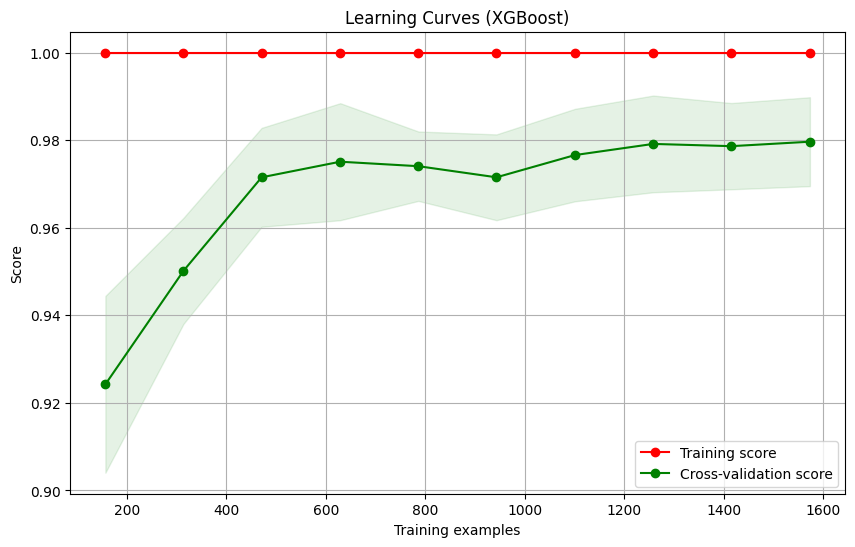


Final Scores for XGBoost:
Training Score: 1.000
Validation Score: 0.980
Gap: 0.020
--------------------------------------------------------------------------------


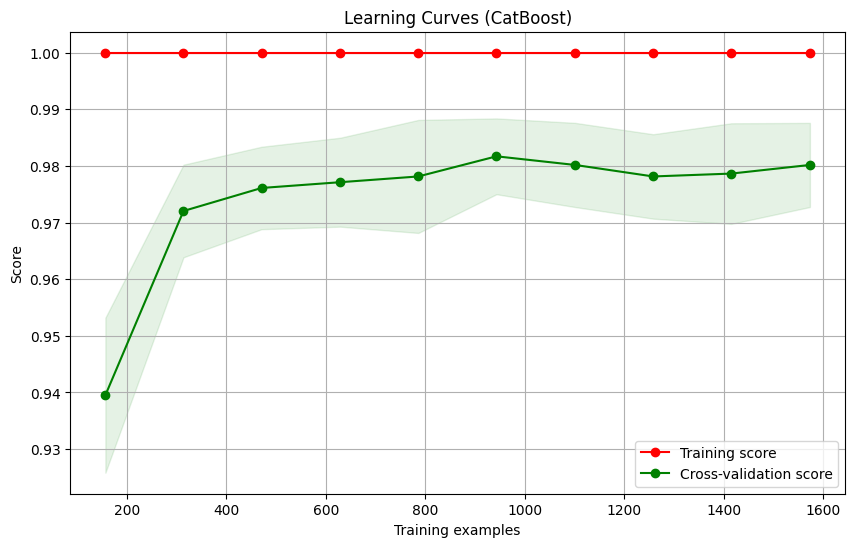


Final Scores for CatBoost:
Training Score: 1.000
Validation Score: 0.980
Gap: 0.020
--------------------------------------------------------------------------------


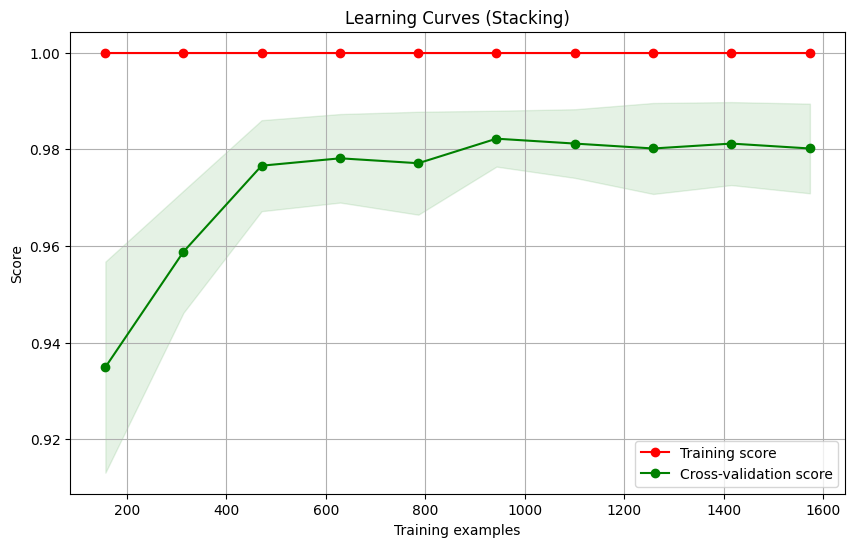


Final Scores for Stacking:
Training Score: 1.000
Validation Score: 0.980
Gap: 0.020
--------------------------------------------------------------------------------


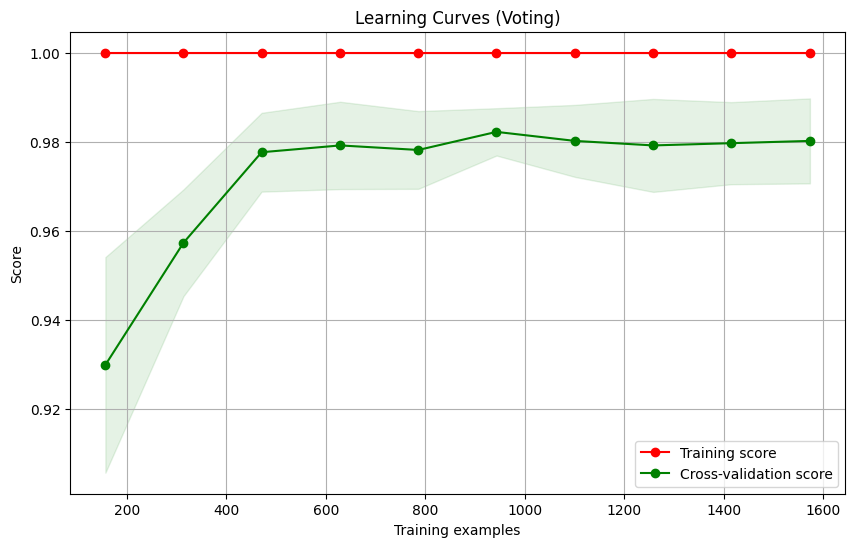


Final Scores for Voting:
Training Score: 1.000
Validation Score: 0.980
Gap: 0.020
--------------------------------------------------------------------------------


In [27]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='accuracy')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    
    plt.legend(loc="best")
    return plt

# Plot learning curves for each model
for model_name, model in models.items():
    title = f"Learning Curves ({model_name})"
    plot_learning_curve(model, title, X_train, y_train, cv=5, n_jobs=-1)
    plt.show()
    
    # Print final training and validation scores
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(.1, 1.0, 10))
    
    final_train_score = np.mean(train_scores[-1])
    final_test_score = np.mean(test_scores[-1])
    
    print(f"\nFinal Scores for {model_name}:")
    print(f"Training Score: {final_train_score:.3f}")
    print(f"Validation Score: {final_test_score:.3f}")
    print(f"Gap: {final_train_score - final_test_score:.3f}")

    print("-" * 80)

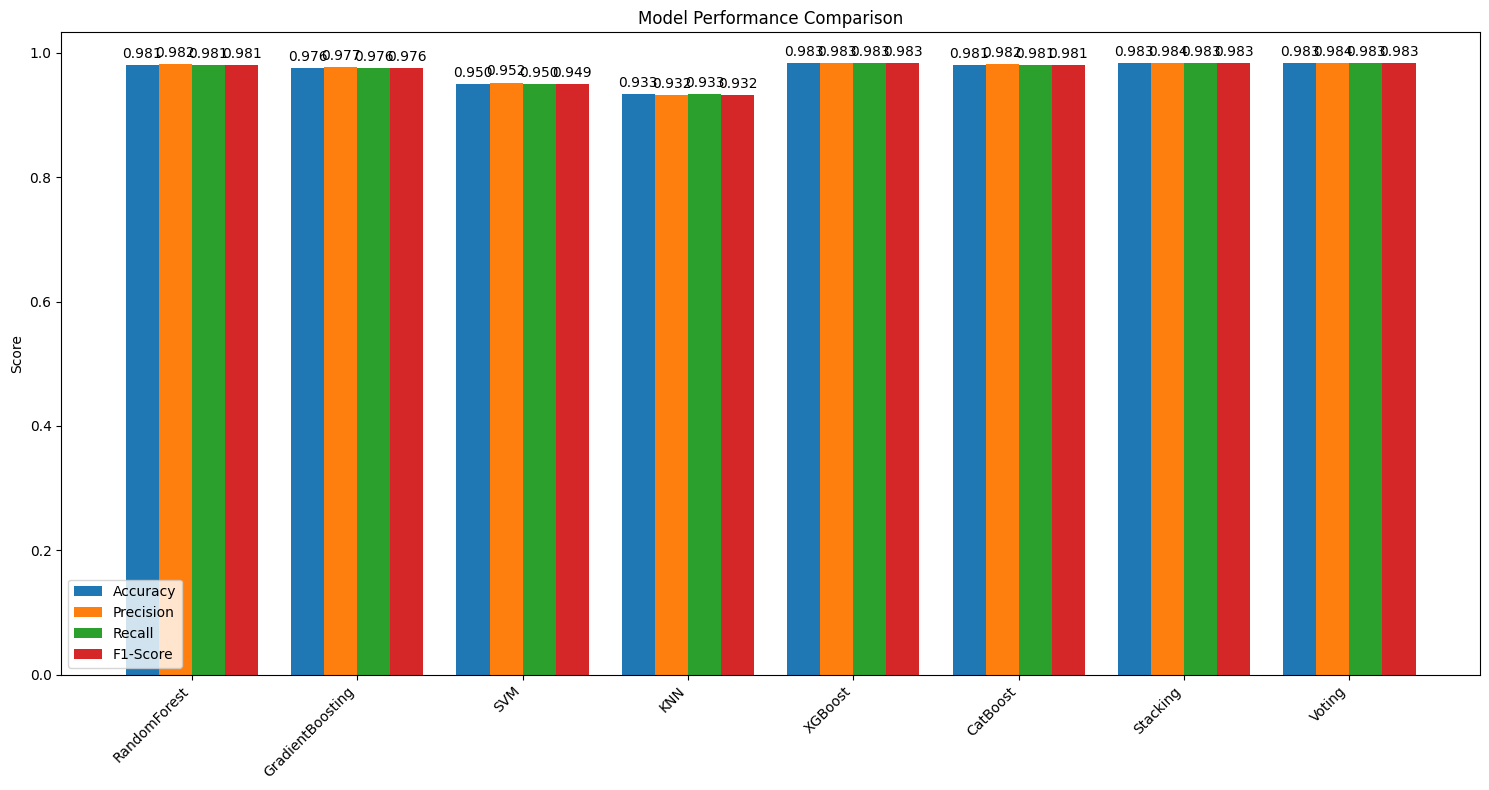


Detailed Model Performance Comparison:
----------------------------------------------------------------------------------------------------
Model                Accuracy   Precision  Recall     F1-Score  
----------------------------------------------------------------------------------------------------
RandomForest         0.981      0.982      0.981      0.981     
GradientBoosting     0.976      0.977      0.976      0.976     
SVM                  0.950      0.952      0.950      0.949     
KNN                  0.933      0.932      0.933      0.932     
XGBoost              0.983      0.983      0.983      0.983     
CatBoost             0.981      0.982      0.981      0.981     
Stacking             0.983      0.984      0.983      0.983     
Voting               0.983      0.984      0.983      0.983     
----------------------------------------------------------------------------------------------------


In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each model
metrics = {
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

model_names = list(models.keys())

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='weighted'))
    metrics['Recall'].append(recall_score(y_test, y_pred, average='weighted'))
    metrics['F1-Score'].append(f1_score(y_test, y_pred, average='weighted'))

# Set up the plot
plt.figure(figsize=(15, 8))
x = np.arange(len(model_names))  # the label locations
width = 0.2  # the width of the bars

# Create bars for each metric
rects1 = plt.bar(x - 1.5*width, metrics['Accuracy'], width, label='Accuracy')
rects2 = plt.bar(x - 0.5*width, metrics['Precision'], width, label='Precision')
rects3 = plt.bar(x + 0.5*width, metrics['Recall'], width, label='Recall')
rects4 = plt.bar(x + 1.5*width, metrics['F1-Score'], width, label='F1-Score')

# Add some text for labels, title and custom x-axis tick labels, etc.
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=45, ha='right')
plt.legend()

# Add value labels on top of each bar
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\nDetailed Model Performance Comparison:")
print("-" * 100)
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-" * 100)
for i, model_name in enumerate(model_names):
    print(f"{model_name:<20} {metrics['Accuracy'][i]:<10.3f} {metrics['Precision'][i]:<10.3f} "
          f"{metrics['Recall'][i]:<10.3f} {metrics['F1-Score'][i]:<10.3f}")
print("-" * 100)